In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('train.csv')

In [ ]:
df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,8:30:00,8:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,5/4/2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  object 
 3   Delivery_person_Ratings      45593 non-null  object 
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [ ]:
df.describe()

,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,17.017729,70.231332,17.465186,70.845702,1.023359
std,8.185109,22.883647,7.335122,21.118812,0.839065
min,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,12.933284,73.170000,12.988453,73.280000,0.000000
50%,18.546947,75.898497,18.633934,76.002574,1.000000
75%,22.728163,78.044095,22.785049,78.107044,2.000000
max,30.914057,88.433452,31.054057,88.563452,3.000000


In [ ]:
# Convert columns to numeric, forcing errors into NaN values
df['Delivery_person_Age'] = pd.to_numeric(df['Delivery_person_Age'], errors='coerce')
df['Delivery_person_Ratings'] = pd.to_numeric(df['Delivery_person_Ratings'], errors='coerce')

In [ ]:
# Fill NaN values with the median (often better for skewed data)
df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)
df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].median(), inplace=True)

/tmp/ipython-input-1137183575.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median(), inplace=True)
/tmp/ipython-input-1137183575.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].me

In [ ]:
df.describe()

,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Vehicle_condition
count,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000,45593.000000
mean,29.584739,4.636552,17.017729,70.231332,17.465186,70.845702,1.023359
std,5.696333,0.327906,8.185109,22.883647,7.335122,21.118812,0.839065
min,15.000000,1.000000,-30.905562,-88.366217,0.010000,0.010000,0.000000
25%,25.000000,4.600000,12.933284,73.170000,12.988453,73.280000,0.000000
50%,30.000000,4.700000,18.546947,75.898497,18.633934,76.002574,1.000000
75%,34.000000,4.800000,22.728163,78.044095,22.785049,78.107044,2.000000
max,50.000000,6.000000,30.914057,88.433452,31.054057,88.563452,3.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  object 
 1   Delivery_person_ID           45593 non-null  object 
 2   Delivery_person_Age          45593 non-null  float64
 3   Delivery_person_Ratings      45593 non-null  float64
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  object 
 9   Time_Orderd                  45593 non-null  object 
 10  Time_Order_picked            45593 non-null  object 
 11  Weatherconditions            45593 non-null  object 
 12  Road_traffic_density         45593 non-null  object 
 13  Vehicle_conditio

In [ ]:
df['Time_Orderd'] = pd.to_datetime(df['Time_Orderd'], format='%H:%M:%S', errors='coerce')
df['Time_Order_picked'] = pd.to_datetime(df['Time_Order_picked'], format='%H:%M:%S', errors='coerce')

In [ ]:
# 1. Extract only the numbers from the string using a regular expression.
#    The regex '(\d+)' finds and "captures" one or more digits.
df['Time_taken(min)'] = df['Time_taken(min)'].str.extract('(\d+)')

# 2. Convert the new column of digit-strings into a proper integer type.
df['Time_taken(min)'] = pd.to_numeric(df['Time_taken(min)'])

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-1346980763.py:3: SyntaxWarning: invalid escape sequence '\d'
  df['Time_taken(min)'] = df['Time_taken(min)'].str.extract('(\d+)')


In [ ]:
# Replace all slashes ('/') with hyphens ('-')
df['Order_Date_Standardized'] = df['Order_Date'].str.replace('/', '-')

In [ ]:
# Convert the standardized column to a datetime object
df['Order_Date_Cleaned'] = pd.to_datetime(df['Order_Date_Standardized'], format='%d-%m-%Y')

In [ ]:
# Create the 'day_of_week' column by extracting the day name
df['day_of_week'] = df['Order_Date_Cleaned'].dt.day_name()

# Create the 'hour_of_day' column by extracting the hour
df['hour_of_day'] = df['Order_Date_Cleaned'].dt.hour

In [ ]:
# Create an empty list to store the names of columns that have the string 'NaN'
columns_with_nan_string = []

# Loop through each column in the DataFrame
for col in df.columns:
    if df[col].dtype == 'object':
        # Clean leading/trailing whitespace from all actual values
        df[col] = df[col].str.strip()
        # Replace various null-like strings with a real NaN
        df[col] = df[col].replace(['nan', 'NaN', 'Null', 'null', ''], np.nan)

# Print the result
if columns_with_nan_string:
    print("The following columns contain the literal string 'NaN':")
    print(columns_with_nan_string)
else:
    print("No columns were found containing the literal string 'NaN'.")

No columns were found containing the literal string 'NaN'.


In [ ]:
import numpy as np

# List of columns you are cleaning
columns_to_clean = [
    'City',
    'multiple_deliveries',
    'Festival',
    'Vehicle_condition',
    'Road_traffic_density',
    'Weatherconditions'
]

# Loop through the columns and replace the lowercase 'nan' string
for col in columns_to_clean:
    df[col] = df[col].replace('nan', np.nan)
    df[col] = df[col].replace('NaN', np.nan)

print("Finished replacing the 'nan' strings with actual NaN values.")

Finished replacing the 'nan' strings with actual NaN values.


In [ ]:
# Count rows that have at least one NaN value
rows_with_nan = df.isna().any(axis=1).sum()

# Get the total number of rows
total_rows = len(df)

# Calculate the percentage
percentage_nan = (rows_with_nan / total_rows) * 100

print(f"Total rows in the DataFrame: {total_rows}")
print(f"Number of rows with at least one NaN value: {rows_with_nan}")
print(f"Percentage of rows with NaN values: {percentage_nan:.2f}%")

Total rows in the DataFrame: 43862
Number of rows with at least one NaN value: 2246
Percentage of rows with NaN values: 5.12%


In [ ]:
# Display the shape of your DataFrame before deleting rows
print(f"Shape before dropping NaNs: {df.shape}")

# Drop all rows that contain any NaN values, modifying the DataFrame in place
df.dropna(inplace=True)

# Reset the index of the DataFrame after dropping rows (good practice)
df.reset_index(drop=True, inplace=True)

# Display the new shape to confirm rows were deleted
print(f"Shape after dropping NaNs: {df.shape}")

Shape before dropping NaNs: (43862, 24)
Shape after dropping NaNs: (41616, 24)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41616 entries, 0 to 41615
Data columns (total 24 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   ID                           41616 non-null  object        
 1   Delivery_person_ID           41616 non-null  object        
 2   Delivery_person_Age          41616 non-null  float64       
 3   Delivery_person_Ratings      41616 non-null  float64       
 4   Restaurant_latitude          41616 non-null  float64       
 5   Restaurant_longitude         41616 non-null  float64       
 6   Delivery_location_latitude   41616 non-null  float64       
 7   Delivery_location_longitude  41616 non-null  float64       
 8   Order_Date                   41616 non-null  object        
 9   Time_Orderd                  41616 non-null  datetime64[ns]
 10  Time_Order_picked            41616 non-null  datetime64[ns]
 11  Weatherconditions            41616 non-nu

**EDA**

*High-Level Performance (The "What")*

1.   What is the typical delivery time?

2.   When are the busiest periods?



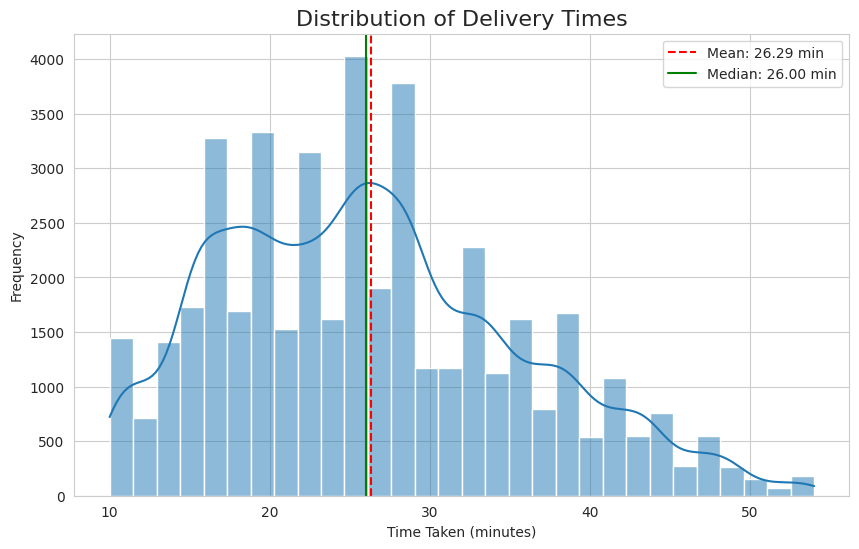

In [ ]:
# --- Analysis of Delivery Time ---
sns.set_style("whitegrid")
# Set the size of the plot
plt.figure(figsize=(10, 6))

# Create a histogram with a Kernel Density Estimate
sns.histplot(df['Time_taken(min)'], kde=True, bins=30)

# Add vertical lines for the mean and median
plt.axvline(df['Time_taken(min)'].mean(), color='red', linestyle='--', label=f"Mean: {df['Time_taken(min)'].mean():.2f} min")
plt.axvline(df['Time_taken(min)'].median(), color='green', linestyle='-', label=f"Median: {df['Time_taken(min)'].median():.2f} min")

# Add titles and labels for clarity
plt.title('Distribution of Delivery Times', fontsize=16)
plt.xlabel('Time Taken (minutes)')
plt.ylabel('Frequency')
plt.legend()

# Show the plot
plt.show()

/tmp/ipython-input-2282570773.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='day_of_week', order=day_order, palette='viridis')


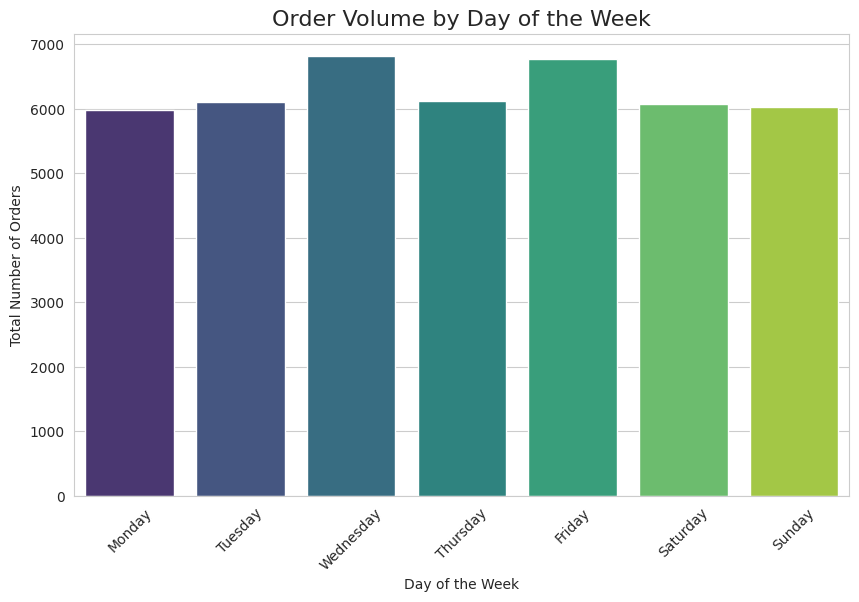

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the visual style for the plot
sns.set_style("whitegrid")

# Define the correct order for the days of the week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

# Create a new figure and set its size
plt.figure(figsize=(10, 6))

# Create the countplot directly
sns.countplot(data=df, x='day_of_week', order=day_order, palette='viridis')

# Add titles and labels for clarity
plt.title('Order Volume by Day of the Week', fontsize=16)
plt.xlabel('Day of the Week')
plt.ylabel('Total Number of Orders')
plt.xticks(rotation=45) # Rotate x-axis labels slightly if they overlap

# Display the plot
plt.show()

*Factor Analysis (The "Why")*


1.   How does City Type, Festival days and Vehicle Conditions impact delivery time?
2.   How do traffic and weather affect performance?
3.  Does the type of order or vehicle matter?



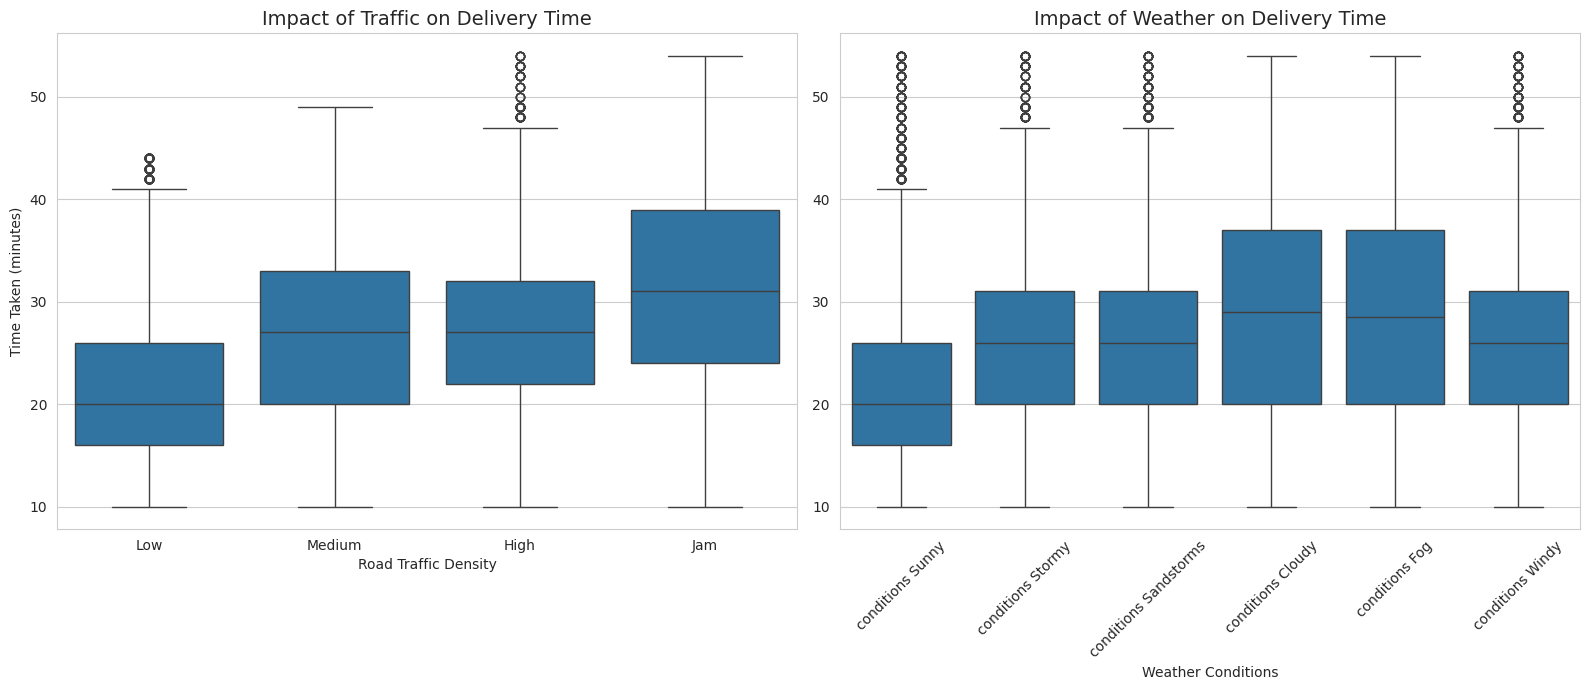

In [ ]:
#How do traffic and weather affect performance?

# --- Traffic Density vs. Time  ---

# Clean the data by stripping leading/trailing whitespace from the column

df['Road_traffic_density'] = df['Road_traffic_density'].str.strip()

# STEP 2: Programmatically create the order list (as before)
ideal_order = ['Low', 'Medium', 'High', 'Jam']
unique_categories_in_data = df['Road_traffic_density'].dropna().unique()
traffic_order = [cat for cat in ideal_order if cat in unique_categories_in_data]

# STEP 3: Create the plots
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

sns.boxplot(data=df, x='Road_traffic_density', y='Time_taken(min)', ax=ax[0], order=traffic_order)
ax[0].set_title('Impact of Traffic on Delivery Time', fontsize=14)
ax[0].set_xlabel('Road Traffic Density')
ax[0].set_ylabel('Time Taken (minutes)')

# --- Weather Conditions vs. Time ---
# strip whitespace from the weather column just in case
df['Weatherconditions'] = df['Weatherconditions'].str.strip()

sns.boxplot(data=df, x='Weatherconditions', y='Time_taken(min)', ax=ax[1])
ax[1].set_title('Impact of Weather on Delivery Time', fontsize=14)
ax[1].set_xlabel('Weather Conditions')
ax[1].set_ylabel('')
ax[1].tick_params(axis='x', rotation=45)

# Display the plots
plt.tight_layout()
plt.show()

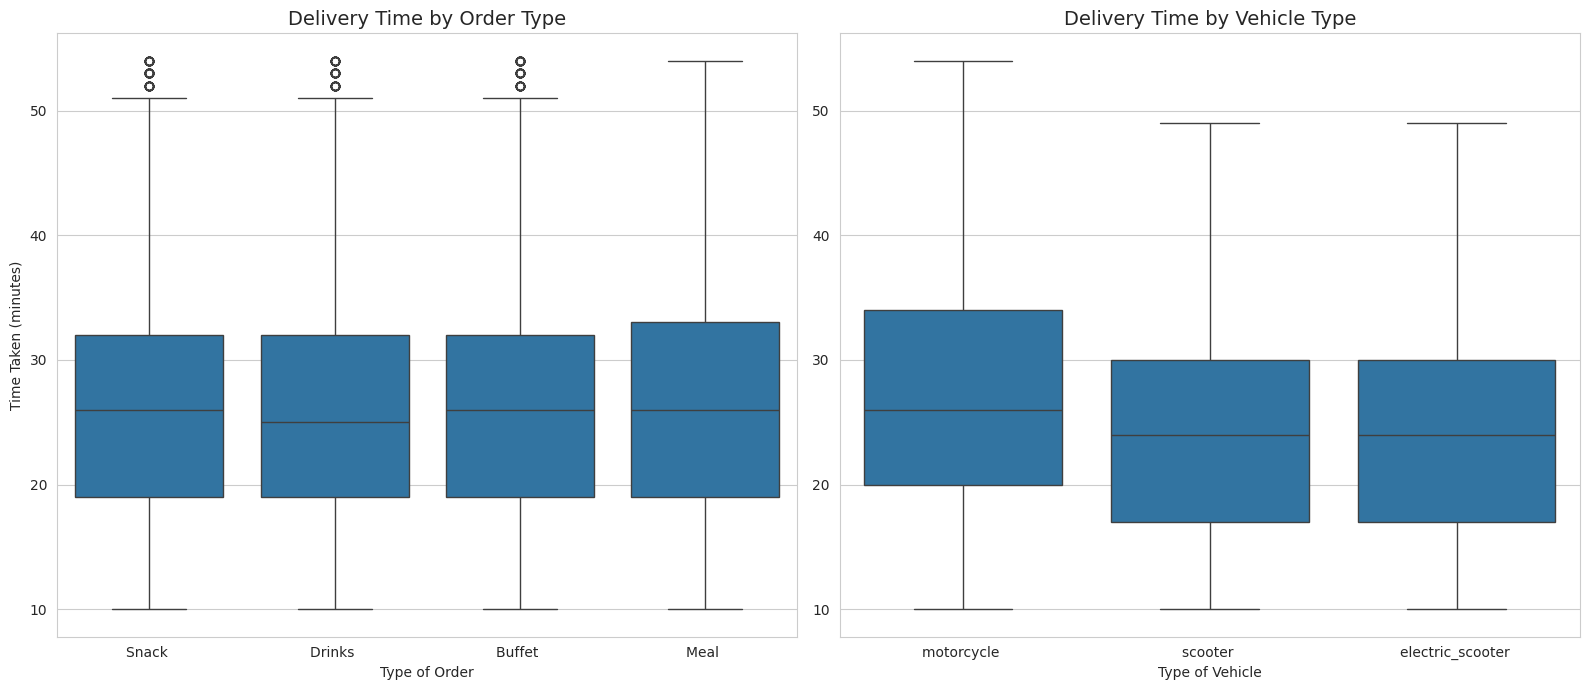

In [ ]:
# Does the type of order or vehicle matter?
# Create a figure with two subplots side-by-side
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# --- Order Type vs. Time ---
sns.boxplot(data=df, x='Type_of_order', y='Time_taken(min)', ax=ax[0])
ax[0].set_title('Delivery Time by Order Type', fontsize=14)
ax[0].set_xlabel('Type of Order')
ax[0].set_ylabel('Time Taken (minutes)')

# --- Vehicle Type vs. Time ---
sns.boxplot(data=df, x='Type_of_vehicle', y='Time_taken(min)', ax=ax[1])
ax[1].set_title('Delivery Time by Vehicle Type', fontsize=14)
ax[1].set_xlabel('Type of Vehicle')
ax[1].set_ylabel('')

# Display the plots
plt.tight_layout()
plt.show()

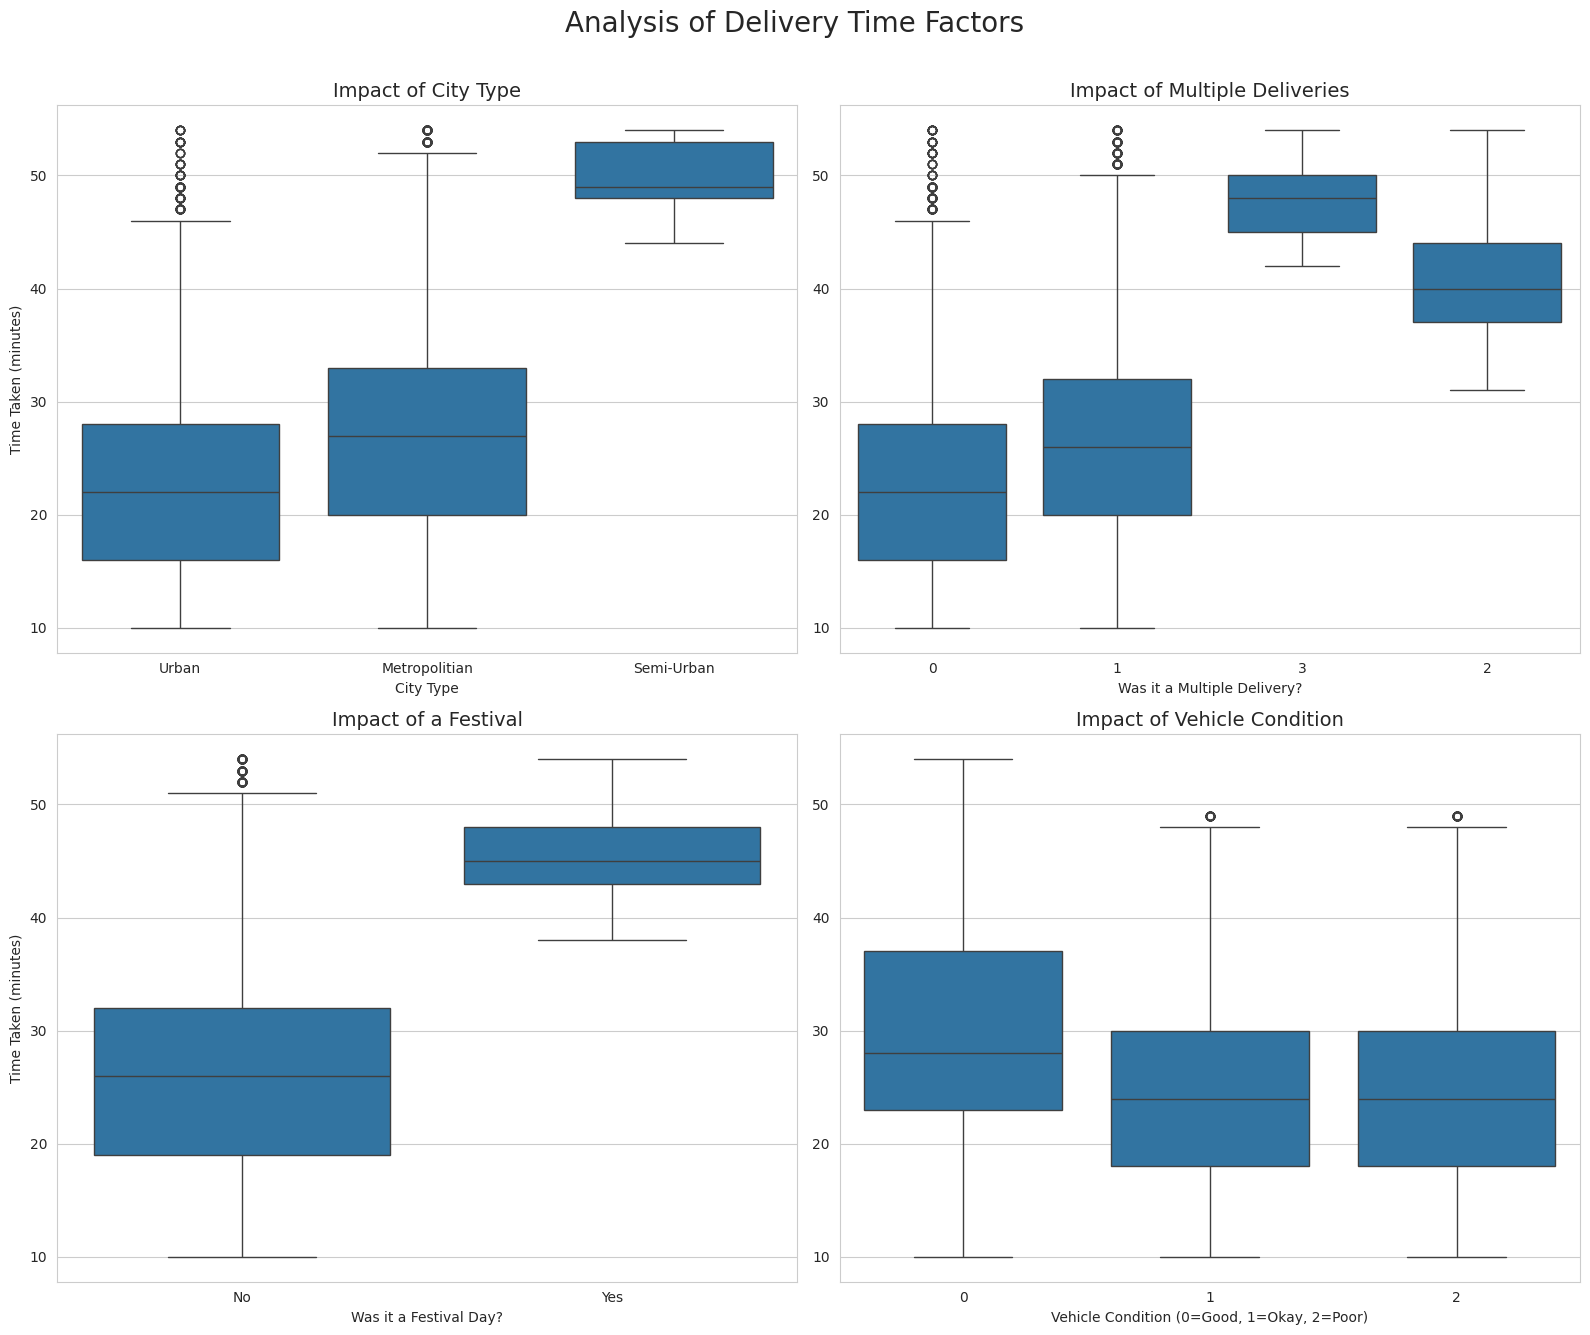

In [ ]:
#How does City Type, Festival days and Vehicle Conditions impact delivery time?
# Set the visual style
sns.set_style("whitegrid")

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.suptitle('Analysis of Delivery Time Factors', fontsize=20)


# 1. Impact of City Type
sns.boxplot(data=df, x='City', y='Time_taken(min)', ax=axes[0, 0])
axes[0, 0].set_title('Impact of City Type', fontsize=14)
axes[0, 0].set_xlabel('City Type')
axes[0, 0].set_ylabel('Time Taken (minutes)')

# 2. Impact of Multiple Deliveries
sns.boxplot(data=df, x='multiple_deliveries', y='Time_taken(min)', ax=axes[0, 1])
axes[0, 1].set_title('Impact of Multiple Deliveries', fontsize=14)
axes[0, 1].set_xlabel('Was it a Multiple Delivery?')
axes[0, 1].set_ylabel('')

# 3. Impact of Festivals
sns.boxplot(data=df, x='Festival', y='Time_taken(min)', ax=axes[1, 0])
axes[1, 0].set_title('Impact of a Festival', fontsize=14)
axes[1, 0].set_xlabel('Was it a Festival Day?')
axes[1, 0].set_ylabel('Time Taken (minutes)')

# 4. Impact of Vehicle Condition
sns.boxplot(data=df, x='Vehicle_condition', y='Time_taken(min)', ax=axes[1, 1])
axes[1, 1].set_title('Impact of Vehicle Condition', fontsize=14)
axes[1, 1].set_xlabel('Vehicle Condition (0=Good, 1=Okay, 2=Poor)')
axes[1, 1].set_ylabel('')

# Adjust layout and show the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

*Delivery Partner Analysis (The "Who")*


1.   Do driver ratings or age correlate with delivery speed?



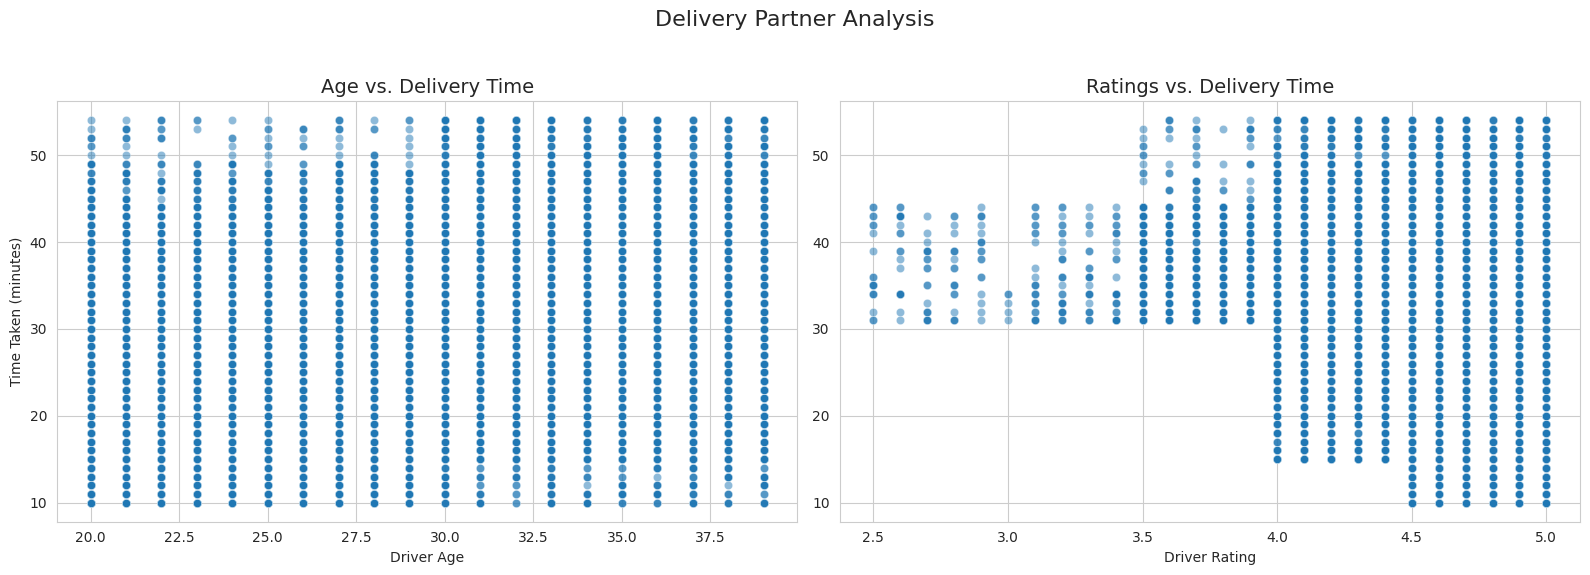

In [ ]:


# Set the visual style for the plots
sns.set_style("whitegrid")

# Create a figure with two subplots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Delivery Partner Analysis', fontsize=16)


# 1. Age vs. Delivery Time
sns.scatterplot(data=df, x='Delivery_person_Age', y='Time_taken(min)', ax=axes[0], alpha=0.5)
axes[0].set_title('Age vs. Delivery Time', fontsize=14)
axes[0].set_xlabel('Driver Age')
axes[0].set_ylabel('Time Taken (minutes)')


# 2. Ratings vs. Delivery Time
sns.scatterplot(data=df, x='Delivery_person_Ratings', y='Time_taken(min)', ax=axes[1], alpha=0.5)
axes[1].set_title('Ratings vs. Delivery Time', fontsize=14)
axes[1].set_xlabel('Driver Rating')
axes[1].set_ylabel('') # Hide y-label for a cleaner look


# Adjust layout and show the plots
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust for suptitle
plt.show()

In [ ]:
# Export the cleaned DataFrame to a new CSV file
# We use index=False to avoid creating an unnecessary column
df.to_csv('cleaned_delivery_data.csv', index=False)

print("Cleaned data has been successfully exported to 'cleaned_delivery_data.csv'")

Cleaned data has been successfully exported to 'cleaned_delivery_data.csv'
